In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
dataset = pd.read_csv('../input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [3]:
dataset.info() #check out the memory consumption: memory usage: 479.2+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
dataset['gender'] = dataset['gender'].astype('category')
dataset['ever_married'] = dataset['ever_married'].astype('category')
dataset['work_type'] = dataset['work_type'].astype('category')
dataset['Residence_type'] = dataset['Residence_type'].astype('category')
dataset['smoking_status'] = dataset['smoking_status'].astype('category')

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
dataset.info() #now, check out the memory consumption: memory usage: 305.3 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   category
 2   age                5110 non-null   float64 
 3   hypertension       5110 non-null   int64   
 4   heart_disease      5110 non-null   int64   
 5   ever_married       5110 non-null   category
 6   work_type          5110 non-null   category
 7   Residence_type     5110 non-null   category
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     5110 non-null   category
 11  stroke             5110 non-null   int64   
dtypes: category(5), float64(3), int64(4)
memory usage: 305.3 KB


### Exporatory Data Analysis

Let's begin Some exploratory data analysis! We will start by checking missing data.

### Missing Data

We can use Seaborn to create a simple heatmap to see where we are missing data.

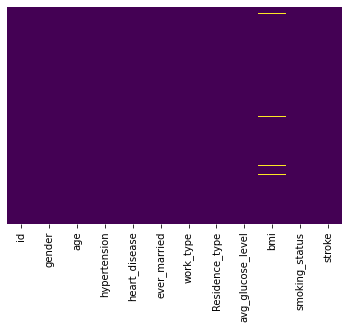

In [7]:
sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

Roughly 5% of the bmi data is missing. The proportion of bmi is likely small enough for reasonable replacement with some form of imputation.

Let's continue on by visualizing some more of the data!

In [8]:
dataset['gender'].value_counts()

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [9]:
dataset[dataset['gender']=='Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [10]:
dataset.drop(labels=3116,axis=0,inplace=True)

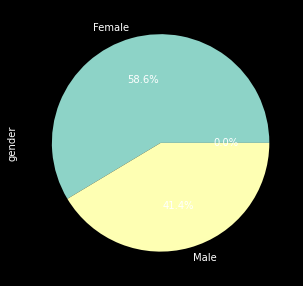

In [11]:
plt.style.use('dark_background')
plt.figure(figsize=(5,5))
dataset['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()

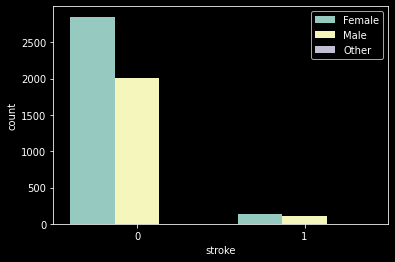

In [12]:
sns.countplot(x='stroke',hue='gender',data=dataset)
plt.legend(loc='upper right', bbox_to_anchor=(1,1))
plt.show()

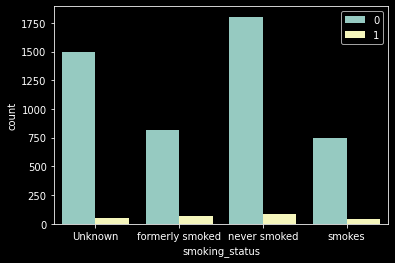

In [13]:
sns.countplot(x='smoking_status',hue='stroke',data=dataset)
plt.legend(loc='upper right', bbox_to_anchor=(1,1))
plt.show()

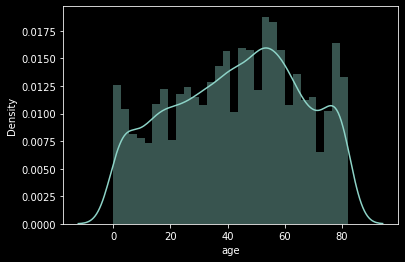

In [14]:
sns.distplot(dataset['age'],kde=True,bins=30)
plt.show()

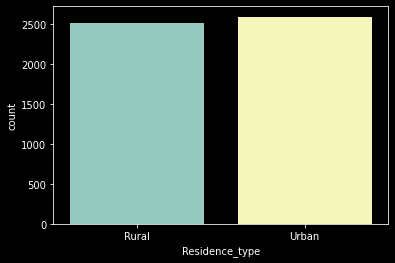

In [15]:
sns.countplot(x='Residence_type',data=dataset)
plt.show()

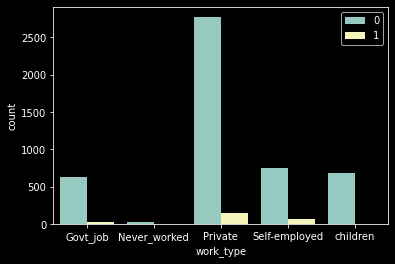

In [16]:
sns.countplot(x='work_type',hue='stroke',data=dataset)
plt.legend(loc='upper right')
plt.show()

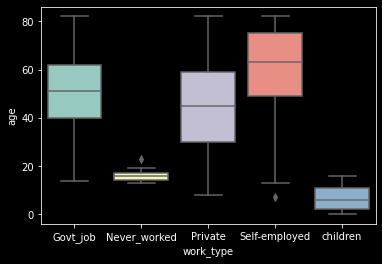

In [17]:
sns.boxplot(x='work_type',y='age',data=dataset)
plt.show()

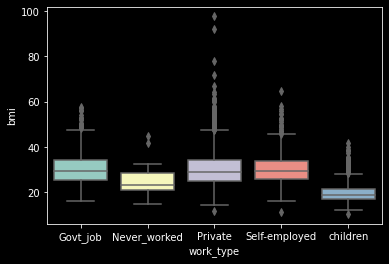

In [18]:
sns.boxplot(x='work_type',y='bmi',data=dataset)
plt.show()

### Data Cleaning:

We want to fill in missing bmi data instead of just dropping the missing data rows. One way to do this is by filling in the mean bmi of all the population. However we can see here that bmi is different for different work_type population. We can see children tend to have low bmi and Private work_type people have high bmi.

In [19]:
print(dataset[dataset['work_type']=='Private']['bmi'].mean())
print(dataset[dataset['work_type']=='Self-employed']['bmi'].mean())
print(dataset[dataset['work_type']=='Govt_job']['bmi'].mean())
print(dataset[dataset['work_type']=='children']['bmi'].mean())
print(dataset[dataset['work_type']=='Never_worked']['bmi'].mean())

30.307437722419927
30.211870967741937
30.522063492063495
20.038002980625933
25.545454545454547


In [20]:
def impute_bmi(cols):
    bmi = cols[0]
    work_type = cols[1]
    
    if pd.isnull(bmi):
        if work_type == 'Private':
            return 30.30
        elif work_type == 'Self-employed':
            return 30.21
        elif work_type == 'Govt_job':
            return 30.52
        elif work_type == 'children':
            return 20.03
        else:
            return 25.54
        
    else:
        return bmi            

Now apply that function!

In [21]:
dataset['bmi'] = dataset[['bmi','work_type']].apply(impute_bmi,axis=1)

<AxesSubplot:>

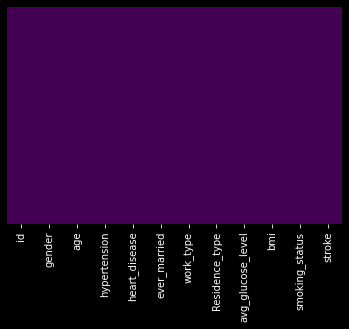

In [22]:
sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')

# Splitting the dataset into feature columns and target column

In [23]:
x = dataset.iloc[:,1:-1].values
y = dataset.iloc[:,-1].values

In [24]:
print(x)

[['Male' 67.0 0 ... 228.69 36.6 'formerly smoked']
 ['Female' 61.0 0 ... 202.21 30.21 'never smoked']
 ['Male' 80.0 0 ... 105.92 32.5 'never smoked']
 ...
 ['Female' 35.0 0 ... 82.99 30.6 'never smoked']
 ['Male' 51.0 0 ... 166.29 25.6 'formerly smoked']
 ['Female' 44.0 0 ... 85.28 26.2 'Unknown']]


# Label Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
x[:,0] = gender_encoder.fit_transform(x[:,0])

married_encoder = LabelEncoder()
x[:,4] = married_encoder.fit_transform(x[:,4])

residence_encoder = LabelEncoder()
x[:,6] = residence_encoder.fit_transform(x[:,6])

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

work_ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[5])],remainder='passthrough')
x = np.array(work_ct.fit_transform(x))

some_ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[-1])],remainder='passthrough')
x = np.array(some_ct.fit_transform(x))

# Splitting the data

In [27]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

# Scalling Our Data

In [28]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
x_train[:,[10,15,16]] = sc_x.fit_transform(x_train[:,[10,15,16]])
x_test[:,[10,15,16]] = sc_x.transform(x_test[:,[10,15,16]])

In [29]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train,y_train)

LogisticRegression()

In [30]:
y_pred = classifier.predict(x_test)

In [31]:
np.concatenate((y_test.reshape((len(y_test),1)), y_pred.reshape((len(y_pred),1))),1)

array([[1, 0],
       [0, 0],
       [0, 0],
       ...,
       [1, 0],
       [0, 0],
       [0, 0]])

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [33]:
confusion_matrix(y_test,y_pred)

array([[968,   0],
       [ 53,   1]])

In [34]:
accuracy_score(y_test,y_pred)

0.9481409001956947

# Conclusion

Because of the biased data we are having higher False Negative rate in our Model.